In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np
import math

from os.path import join
import os
from functools import partial
import pathlib
import shutil

In [2]:
comparisons = {
    "MPAS": "/glade/derecho/scratch/dkimpara/goes_10km_train/baselines/mpas_forecasts",
    "ML": "/glade/derecho/scratch/dkimpara/goes_10km_train/baselines/wx_inverted",
    "Persistence": "/glade/derecho/scratch/dkimpara/goes_10km_train/baselines/persistence_forecasts",
    "Climo": "/glade/derecho/scratch/dkimpara/goes_10km_train/baselines/climo_forecasts",
}
colors = {
    "Persistence": "0.5",
    "Climo": "0",
}  # defaults to None in .get

timestep = 0.5

dfs = {
    k: pd.read_parquet(join(path, "verif.parquet")) for k, path in comparisons.items()
}
dfs = {k: df[df["forecast_step"] != 21.0] for k, df in dfs.items()}

In [3]:
def plot_1d_metric(metric, channel):
    col_name = f"{metric}_C{channel:02}"

    fig, ax = plt.subplots(figsize=(10, 6))

    for model, df in dfs.items():
        ax.plot(
            df.forecast_step * timestep,
            df[col_name],
            label=model,
            color=colors.get(model, None),
        )

    ticks = [0.5] + [
        int(k) for k in range(1, math.ceil(max(df.forecast_step) * timestep + 1))
    ]
    ax.set_xticks(ticks)

    ax.grid()
    ax.legend()

    ax.set_xlim(left=0.0)
    if metric != "ME":
        ax.set_ylim(bottom=0.0)
    else:
        ax.axhline(0.0, color="0")

    ax.set_xlabel("Forecast hour")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} C{channel:02}")
    plt.show()

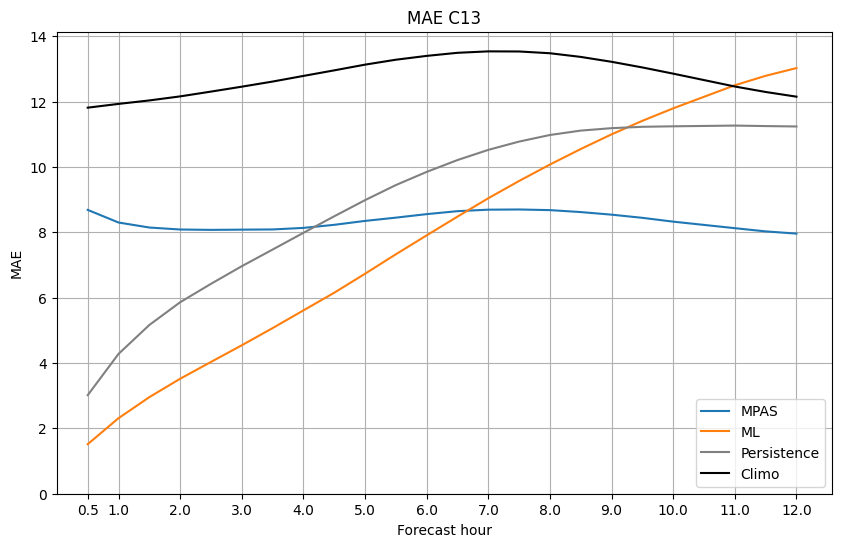

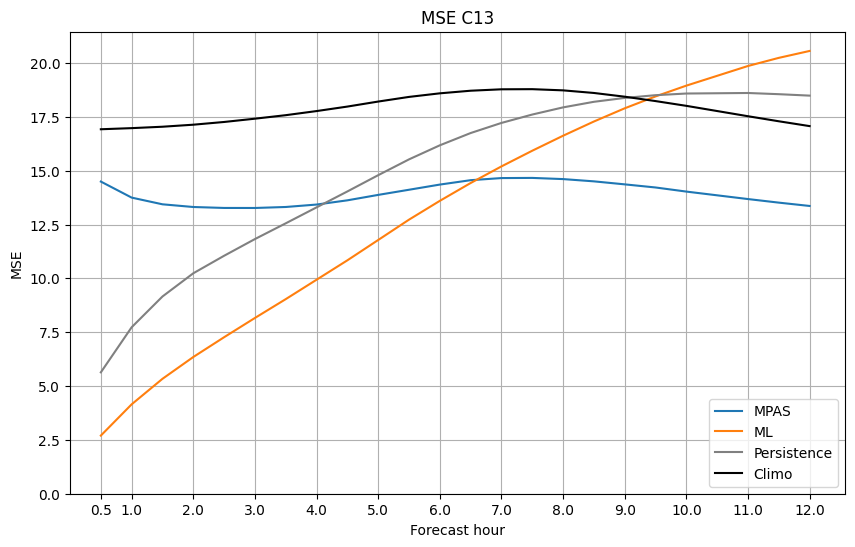

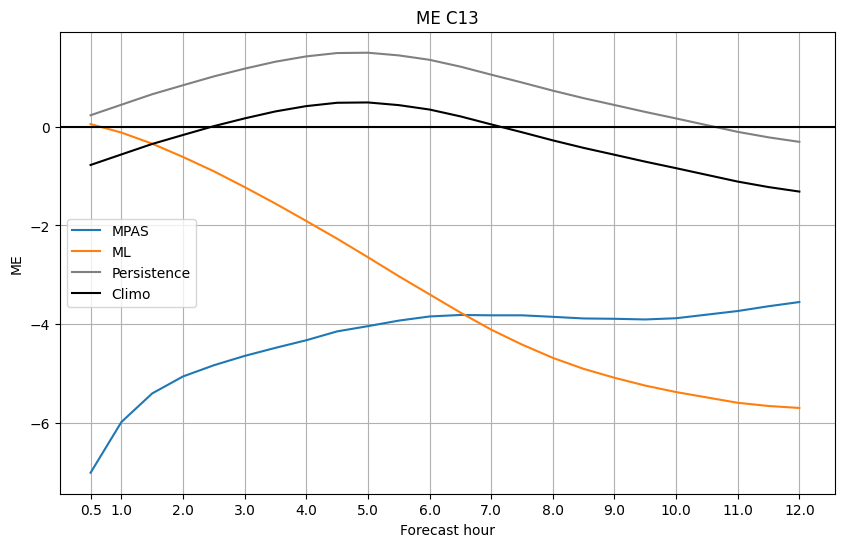

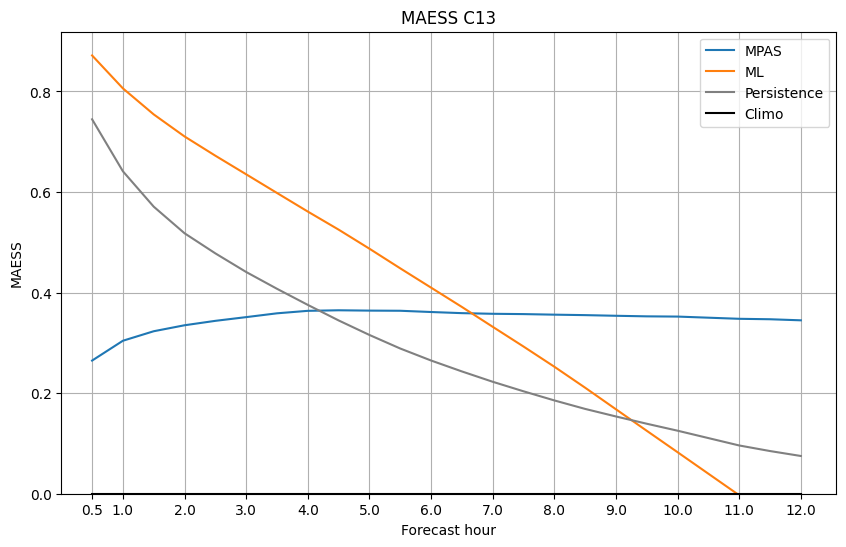

In [4]:
plot_1d_metric("MAE", 13)
plot_1d_metric("MSE", 13)
plot_1d_metric("ME", 13)
plot_1d_metric("MAESS", 13)

/glade/derecho/scratch/dkimpara/tmp/ipykernel_70154/3931927435.py:15: RuntimeWarning: divide by zero encountered in divide
  wavelengths = 1 / np.fft.rfftfreq(min_c * 2, d=dx)[:-1]


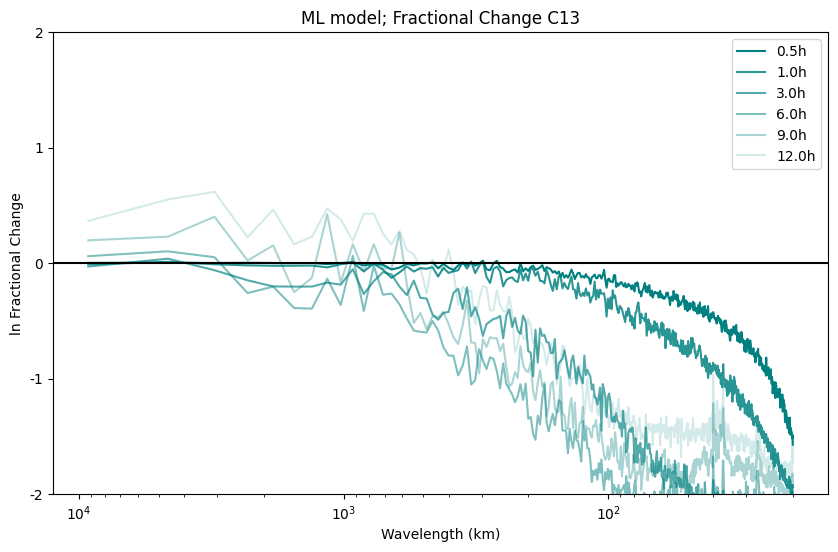

/glade/derecho/scratch/dkimpara/tmp/ipykernel_70154/3931927435.py:15: RuntimeWarning: divide by zero encountered in divide
  wavelengths = 1 / np.fft.rfftfreq(min_c * 2, d=dx)[:-1]


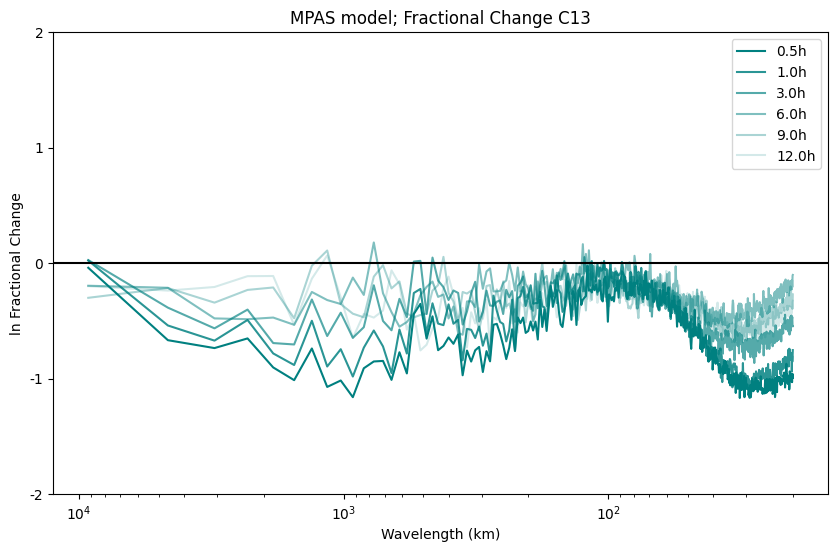

/glade/derecho/scratch/dkimpara/tmp/ipykernel_70154/3931927435.py:15: RuntimeWarning: divide by zero encountered in divide
  wavelengths = 1 / np.fft.rfftfreq(min_c * 2, d=dx)[:-1]


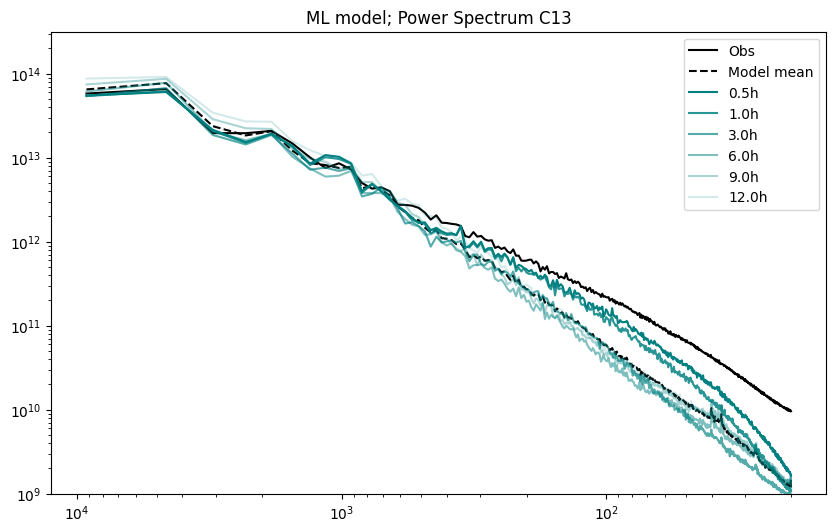

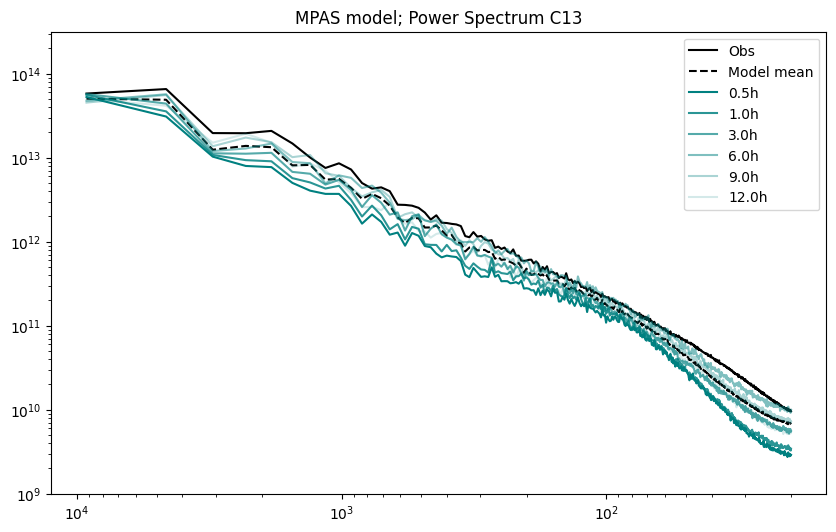

In [5]:
def compute_mean_fft(true_fft):
    """
    true_fft: iterable of 1d arrays
    """
    total = 0.0
    num_rows = 0
    for row in true_fft:
        if not any(np.isnan(row)):
            total += row
            num_rows += 1
    return total / num_rows


def compute_wavelengths(wavenumbers, dx):
    min_c = len(wavenumbers)
    wavelengths = 1 / np.fft.rfftfreq(min_c * 2, d=dx)[:-1]
    return wavelengths


def plot_fft_channel(model, channel, forecast_hours, color="teal", ylims=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    true_ffts = dfs["Persistence"][f"FFT_true_C{channel:02}"]
    true_fft = compute_mean_fft(true_ffts)

    xlabel = compute_wavelengths(true_fft, 10)

    ax.loglog(xlabel, true_fft, label="Obs", color="0")

    df = dfs[model]
    forecast_steps = (np.array(forecast_hours) / timestep).astype(int)
    col_name = f"FFT_C{channel:02}"

    #### plot model mean ####
    mean_fft = compute_mean_fft(df[col_name])
    ax.loglog(xlabel, mean_fft, label="Model mean", color="0", linestyle="dashed")

    #### plot forecast steps #####
    df = df[df["forecast_step"].isin(forecast_steps)]
    i = 0
    for _, row in df.iterrows():
        spectrum = row[col_name]
        ax.loglog(
            xlabel,
            spectrum,
            label=f"{row["forecast_step"] * timestep}h",
            color=color,
            alpha=(len(df) - i) / len(df),
        )
        i += 1

    if ylims:
        ax.set_ylim(*ylims)
    ax.set_xlim(ax.get_xlim()[::-1])

    ax.set_title(f"{model} model; Power Spectrum C{channel:02}")
    ax.legend()
    plt.show()


def plot_fft_fc_channel(
    model, channel, forecast_hours, color="teal", ylims=[-2, 2], base=np.e
):
    fig, ax = plt.subplots(figsize=(10, 6))
    true_ffts = dfs["Persistence"]

    df = dfs[model]
    forecast_steps = (np.array(forecast_hours) / timestep).astype(int)

    #### plot forecast steps #####
    #### fractional change against obs #####
    for i, fs in enumerate(forecast_steps):
        true_fft = true_ffts[true_ffts["forecast_step"] == fs][
            f"FFT_true_C{channel:02}"
        ]
        pred_fft = df[df["forecast_step"] == fs][f"FFT_C{channel:02}"]
        frac_change = (pred_fft / true_fft).values[0]

        xlabel = compute_wavelengths(frac_change, 10)

        ax.plot(
            xlabel,
            frac_change,
            label=f"{fs * timestep}h",
            color=color,
            alpha=(len(forecast_steps) - i) / len(forecast_steps),
        )
    ax.set_xscale("log", base=10)
    ax.set_yscale("log", base=np.e)
    ax.set_xlim(ax.get_xlim()[::-1])

    ax.axhline(1.0, color="0")

    exponents = np.arange(ylims[0], ylims[1] + 1)
    yticks = np.e**exponents
    ax.set_yticks(yticks)
    ax.set_yticklabels(exponents)

    if ylims:
        ax.set_ylim(np.e ** ylims[0], np.e ** ylims[1])

    ax.set_xlabel("Wavelength (km)")
    ax.set_ylabel("ln Fractional Change")
    ax.set_title(f"{model} model; Fractional Change C{channel:02}")
    ax.legend()
    plt.show()


forecast_hours = [0.5, 1, 3, 6, 9, 12]

for model in ["ML", "MPAS"]:
    plot_fft_fc_channel(model, 13, forecast_hours)

for model in ["ML", "MPAS"]:
    plot_fft_channel(model, 13, forecast_hours, ylims=[1e9, 10**14.5])